In [701]:
# CLUSTERING

In [703]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans,DBSCAN
from sklearn.metrics import silhouette_score

In [705]:
df = pd.read_excel("EastWestAirlines.xlsx", sheet_name="data")
df.head()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1


In [706]:
df = df.drop(['ID#'], axis=1)
df.head()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,28143,0,1,1,1,174,1,0,0,7000,0
1,19244,0,1,1,1,215,2,0,0,6968,0
2,41354,0,1,1,1,4123,4,0,0,7034,0
3,14776,0,1,1,1,500,1,0,0,6952,0
4,97752,0,4,1,1,43300,26,2077,4,6935,1


In [707]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Balance            3999 non-null   int64
 1   Qual_miles         3999 non-null   int64
 2   cc1_miles          3999 non-null   int64
 3   cc2_miles          3999 non-null   int64
 4   cc3_miles          3999 non-null   int64
 5   Bonus_miles        3999 non-null   int64
 6   Bonus_trans        3999 non-null   int64
 7   Flight_miles_12mo  3999 non-null   int64
 8   Flight_trans_12    3999 non-null   int64
 9   Days_since_enroll  3999 non-null   int64
 10  Award?             3999 non-null   int64
dtypes: int64(11)
memory usage: 343.8 KB


In [708]:
df.shape

(3999, 11)

In [709]:
df.describe()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
count,3.999000e+03,3999.000000,3999.000000,3999.000000,3999.000000,3999.000000,3999.00000,3999.000000,3999.000000,3999.00000,3999.000000
mean,7.360133e+04,144.114529,2.059515,1.014504,1.012253,17144.846212,11.60190,460.055764,1.373593,4118.55939,0.370343
std,1.007757e+05,773.663804,1.376919,0.147650,0.195241,24150.967826,9.60381,1400.209171,3.793172,2065.13454,0.482957
min,0.000000e+00,0.000000,1.000000,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,2.00000,0.000000
25%,1.852750e+04,0.000000,1.000000,1.000000,1.000000,1250.000000,3.00000,0.000000,0.000000,2330.00000,0.000000
50%,4.309700e+04,0.000000,1.000000,1.000000,1.000000,7171.000000,12.00000,0.000000,0.000000,4096.00000,0.000000
75%,9.240400e+04,0.000000,3.000000,1.000000,1.000000,23800.500000,17.00000,311.000000,1.000000,5790.50000,1.000000
max,1.704838e+06,11148.000000,5.000000,3.000000,5.000000,263685.000000,86.00000,30817.000000,53.000000,8296.00000,1.000000


In [715]:
df.isnull().sum()

Balance              0
Qual_miles           0
cc1_miles            0
cc2_miles            0
cc3_miles            0
Bonus_miles          0
Bonus_trans          0
Flight_miles_12mo    0
Flight_trans_12      0
Days_since_enroll    0
Award?               0
dtype: int64

In [716]:
## ->The basic information tells that the dataset contains only numeric (integer) values and the values are non-zero.

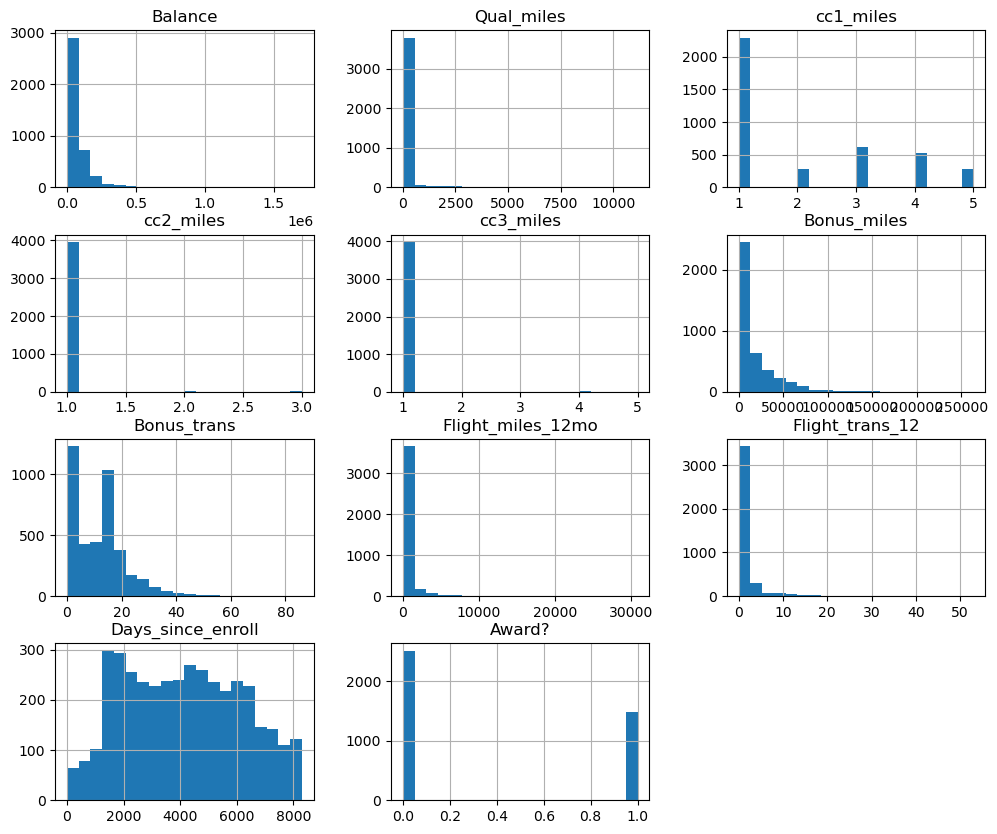

In [717]:
df.hist(figsize=(12,10), bins=20)
plt.show()

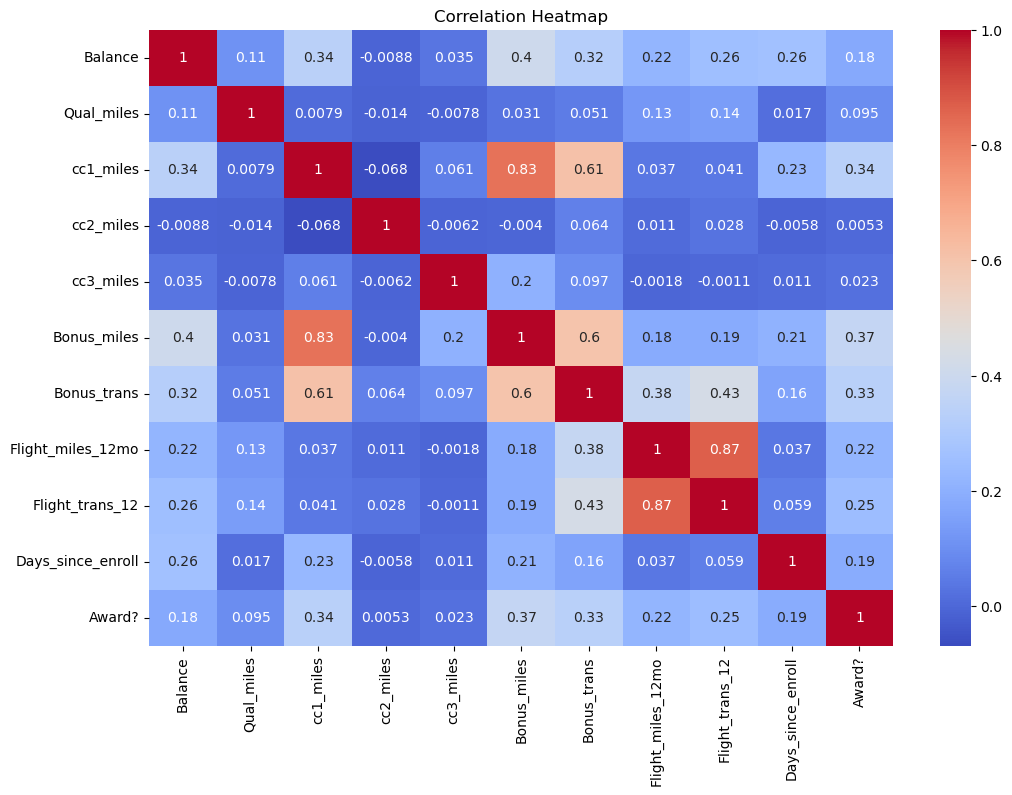

In [718]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

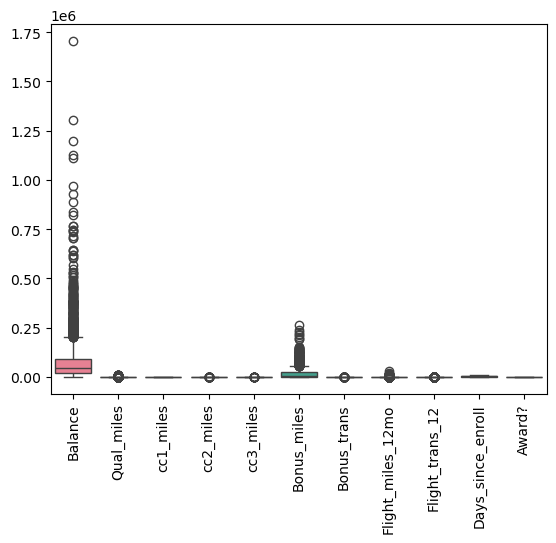

In [719]:
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

In [720]:
## -> Outliers are heavy in the 'Balance' column, and slightly present in 'Bonus_Miles' compared to the former.

In [721]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

filtered_df = df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]

In [722]:
filtered_df = filtered_df.drop(columns=['Cluster'],errors='ignore')

In [723]:
## -> Presence of outliers have been removed, and the values are adjusted. No more outliers exist.

In [724]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(filtered_df)

In [725]:
## ->The dataset has been scaled down, for improving clustering results. Scaling ensures that all features contribute equally to clustering.

In [726]:
scaled_df = pd.DataFrame(scaled_data)

print(scaled_df.std().sort_values())

1     0.000000
3     0.000000
4     0.000000
10    1.000174
2     1.000174
7     1.000174
0     1.000174
5     1.000174
9     1.000174
6     1.000174
8     1.000174
dtype: float64


In [727]:
## -> Feature columns 1,3 and 4 have std=0, meaning they dont have any variations after scaling down. They contribute nothing to the clustering but moreover, contributes negatively to the algorithm.
## -> These columns requires to be dropped from the dataset.

In [728]:
low_variance_cols = scaled_df.columns[scaled_df.std() == 0]

print(low_variance_cols)

scaled_df = scaled_df.drop(columns=low_variance_cols)

Index([1, 3, 4], dtype='int64')


In [729]:
## -> The columns 1,3 and 4 are dropped and the rest of the columns are saved into 'scaled_df'

In [730]:
scaled_data = scaled_df.values

In [731]:
## -> The dataset after removing the columns are converted back into values to feed the model.

In [732]:
# KMeans

In [733]:
wcss = []

for i in range(1,11):

    kmeans = KMeans(n_clusters=i,random_state=42)

    kmeans.fit(scaled_data)

    wcss.append(kmeans.inertia_)

In [734]:
## KMeans Elbow Value and Plot

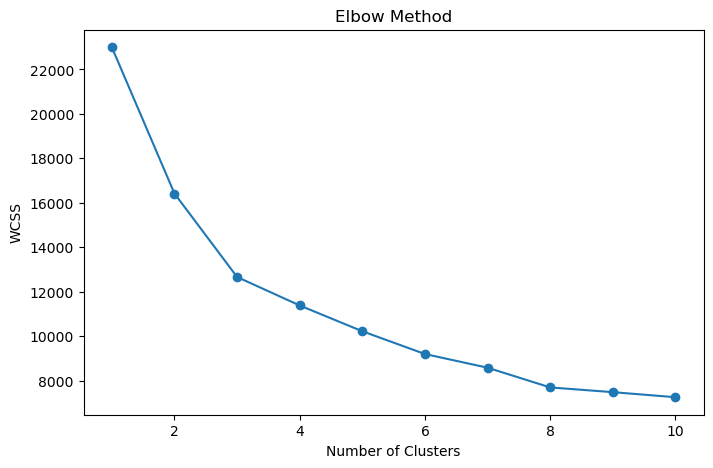

In [735]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11),wcss,marker='o')

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.show()

In [738]:
kmeans = KMeans(n_clusters=2,random_state=42)

kmeans_labels = kmeans.fit_predict(scaled_data)

In [739]:
kmeans_score = silhouette_score(scaled_data,kmeans_labels)

print("KMeans Silhouette Score:", kmeans_score)

KMeans Silhouette Score: 0.32241400527279074


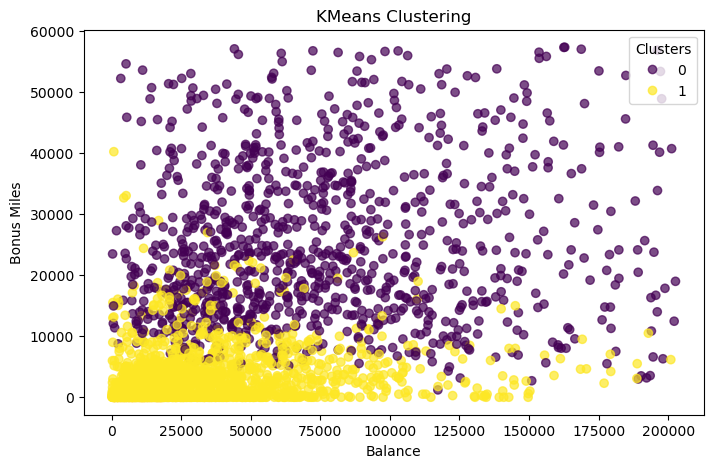

In [740]:
plt.figure(figsize=(8,5))

scatter = plt.scatter(filtered_df['Balance'],filtered_df['Bonus_miles'],c=kmeans_labels,alpha=0.7)

plt.title("KMeans Clustering")

plt.xlabel("Balance")

plt.ylabel("Bonus Miles")

plt.legend(*scatter.legend_elements(),title="Clusters")

plt.show()

In [741]:
# HIERARCHICAL CLUSTERING

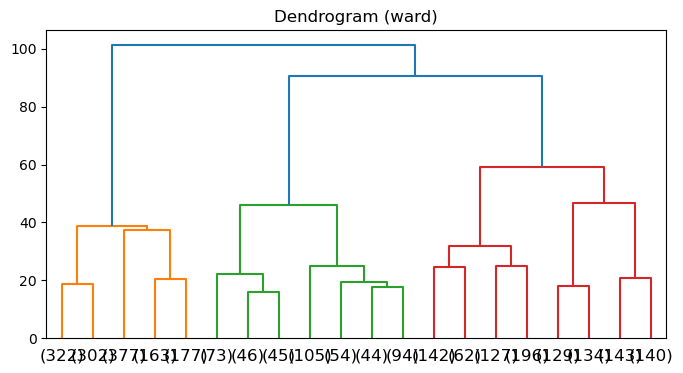

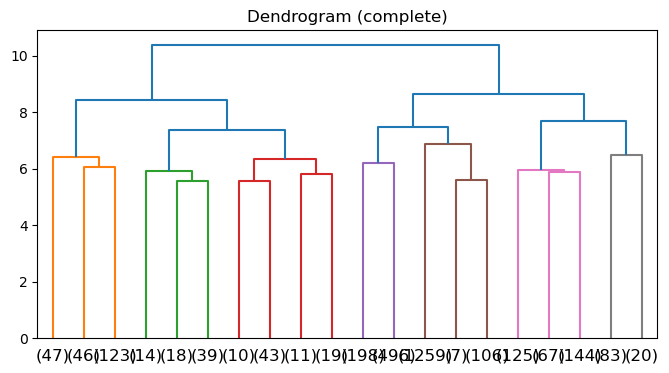

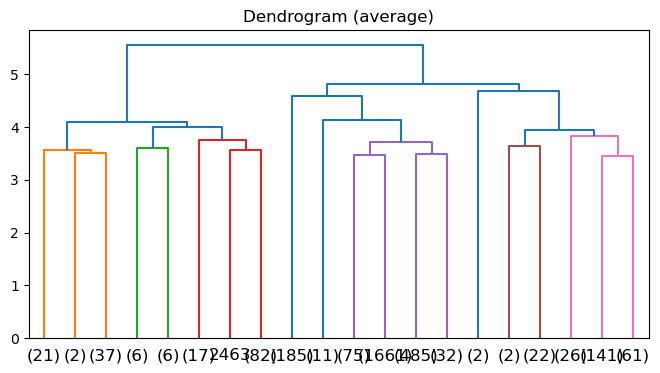

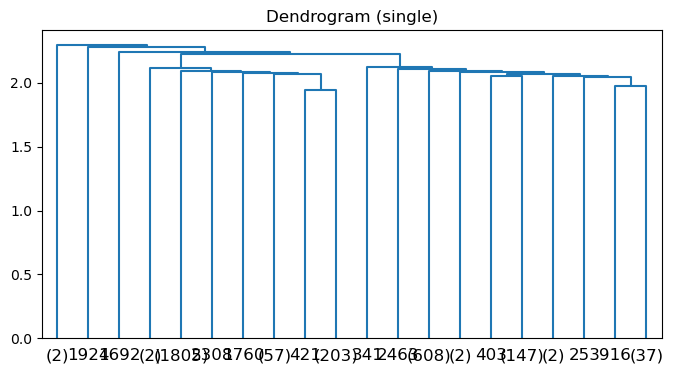

In [742]:
from scipy.cluster.hierarchy import dendrogram, linkage

methods = ['ward', 'complete', 'average', 'single']

for method in methods:
    plt.figure(figsize=(8,4))
    linkage_matrix = linkage(scaled_data, method=method)
    
    dendrogram(linkage_matrix, truncate_mode='lastp', p=20)
    plt.title(f"Dendrogram ({method})")
    plt.show()

In [743]:
## All the variations of heirarchical clustering are considered and compared here.

In [744]:
from sklearn.cluster import AgglomerativeClustering

for method in ['ward', 'complete', 'average']:
    hc = AgglomerativeClustering(n_clusters=2, linkage=method)
    labels = hc.fit_predict(scaled_data)
    
    score = silhouette_score(scaled_data, labels)
    print(f"{method} linkage Score: {score}")

ward linkage Score: 0.2447292192692489
complete linkage Score: 0.36049608968389824
average linkage Score: 0.3645915991381673


In [745]:
## The comparison of silhouette scores of the different methods, Ward Linkage has the highest score, so it is selected as the best method. 

In [746]:
hc_ward = AgglomerativeClustering(n_clusters=2, linkage='average')

hc_ward_labels = hc_ward.fit_predict(scaled_data)

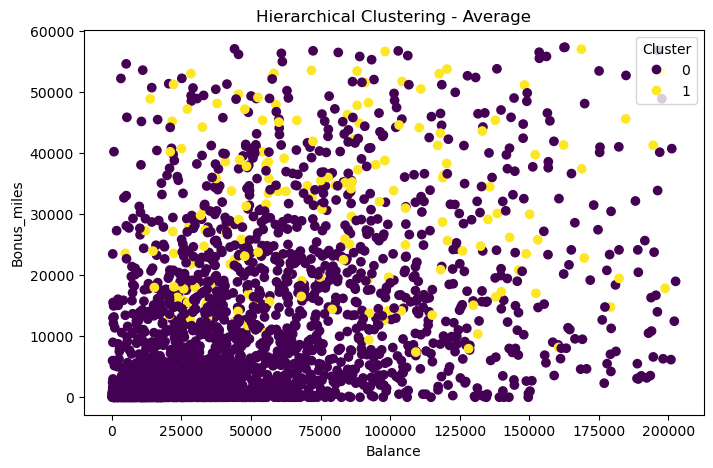

In [747]:
plt.figure(figsize=(8,5))

hscatter=plt.scatter(filtered_df['Balance'],filtered_df['Bonus_miles'],c=hc_ward_labels)

plt.title("Hierarchical Clustering - Average")

plt.xlabel("Balance")

plt.ylabel("Bonus_miles")

plt.legend(*hscatter.legend_elements(),title="Cluster")

plt.show()

In [748]:
## -> For visualization, filtered_df has been used, as scaled down data gives straight lines, which are not that helpful in reading the plot.

In [749]:
# DSCAN 

In [750]:
for eps in [0.5, 0.8, 1.0]:

    for min_samples in [3,5,7]:

        dbscan = DBSCAN(eps=eps,min_samples=min_samples)

        labels = dbscan.fit_predict(scaled_data)

        unique_clusters = len(set(labels))

        if unique_clusters > 1:

            score = silhouette_score(scaled_data,labels)

            print("eps:",eps,"min_samples:",min_samples,"score:",score)

eps: 0.5 min_samples: 3 score: -0.18516724241291455
eps: 0.5 min_samples: 5 score: -0.1295237260152701
eps: 0.5 min_samples: 7 score: -0.1251860474481334
eps: 0.8 min_samples: 3 score: 0.04549480075448105
eps: 0.8 min_samples: 5 score: 0.06914157301161811
eps: 0.8 min_samples: 7 score: 0.061773216231064236
eps: 1.0 min_samples: 3 score: 0.050407665141451855
eps: 1.0 min_samples: 5 score: 0.10323607683452647
eps: 1.0 min_samples: 7 score: 0.18209474990708155


In [752]:
dbscan = DBSCAN(eps=1.0,min_samples=7)

dbscan_labels = dbscan.fit_predict(scaled_data)

In [753]:
if len(set(dbscan_labels)) > 1:

    dbscan_score = silhouette_score(scaled_data,dbscan_labels)

    print("DBSCAN Score:", dbscan_score)

else:

    print("DBSCAN could not form proper clusters")

DBSCAN Score: 0.18209474990708155


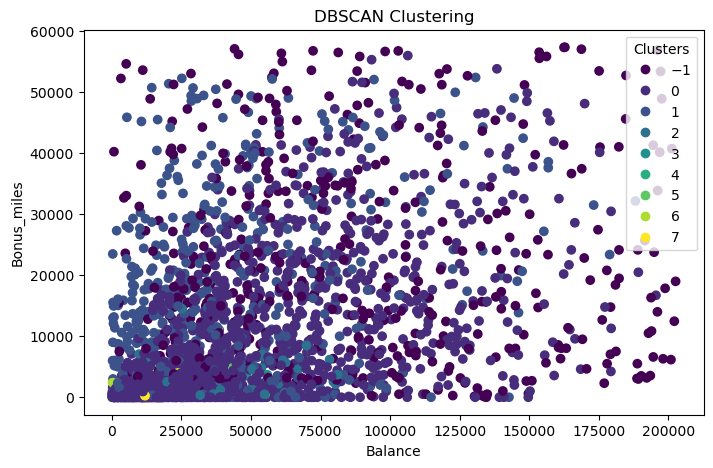

In [755]:
plt.figure(figsize=(8,5))

dbscatter=plt.scatter(
    filtered_df['Balance'],
    filtered_df['Bonus_miles'],
    c=dbscan_labels
)

plt.title("DBSCAN Clustering")

plt.xlabel("Balance")

plt.ylabel("Bonus_miles")

plt.legend(*dbscatter.legend_elements(),title="Clusters")

plt.show()

In [756]:
print("KMeans Score:", silhouette_score(scaled_data, kmeans_labels))
print("Hierarchical Score:", silhouette_score(scaled_data, hc_ward_labels))
print("DSCAN Score:", silhouette_score(scaled_data, dbscan_labels))

KMeans Score: 0.32241400527279074
Hierarchical Score: 0.3645915991381673
DSCAN Score: 0.18209474990708155


In [778]:
## -> KMeans produced compact clusters and showed better separation according to silhouette score. The elbow method indicated that 2 clusters were optimal for the dataset.
## -> Hierarchical clustering using Average linkage produced meaningful hierarchical grouping. Different linkage methods produced varying cluster compactness.
## -> DBSCAN identified dense regions and noise points. Clustering performance varied significantly depending on epsilon and min_samples values.

In [779]:
# -> All the parameters have been checked and the best parameters have been chosen for each cluster, with the help of Sihouette scores.